# Bonus 3: Monte Carlo Simulation (5-Year NAV Projection)

Projecting NAV growth over 5 years (1260 trading days) with uncertainty bands using Geometric Brownian Motion.

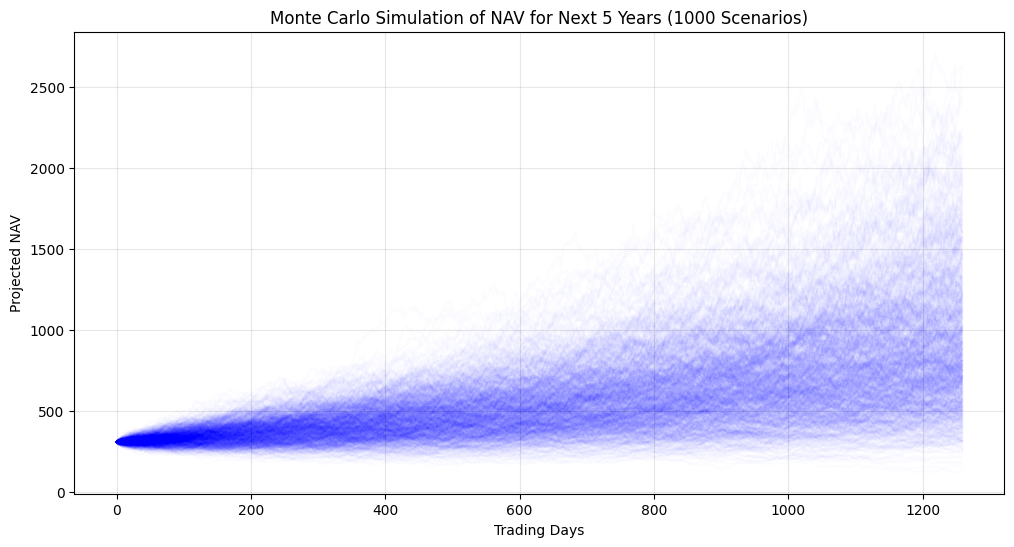

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../bluestock_mf.db')

# Fetch NAV for a top fund
df_nav = pd.read_sql("SELECT date, nav FROM fact_nav WHERE amfi_code = 119598 ORDER BY date", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav.set_index('date', inplace=True)
df_nav['daily_return'] = df_nav['nav'].pct_change()
df_nav.dropna(inplace=True)

# Parameters
mu = df_nav['daily_return'].mean()
sigma = df_nav['daily_return'].std()
days = 1260  # 5 years (252 * 5)
simulations = 1000
start_nav = df_nav['nav'].iloc[-1]

np.random.seed(42)
sim_returns = np.random.normal(mu, sigma, (days, simulations))
sim_navs = np.zeros_like(sim_returns)
sim_navs[0] = start_nav

for t in range(1, days):
    sim_navs[t] = sim_navs[t-1] * (1 + sim_returns[t])

plt.figure(figsize=(12, 6))
plt.plot(sim_navs, color='blue', alpha=0.01)
plt.title('Monte Carlo Simulation of NAV for Next 5 Years (1000 Scenarios)')
plt.xlabel('Trading Days')
plt.ylabel('Projected NAV')
plt.grid(True, alpha=0.3)
plt.savefig('../reports/charts/monte_carlo_nav.png', dpi=300)
plt.show()

In [2]:
# Calculate Percentiles
final_navs = sim_navs[-1, :]
print(f"Current NAV: {start_nav:.2f}")
print(f"Median Expected NAV (5 yrs): {np.percentile(final_navs, 50):.2f}")
print(f"95% Confidence Interval: [{np.percentile(final_navs, 2.5):.2f}, {np.percentile(final_navs, 97.5):.2f}]")

Current NAV: 309.20
Median Expected NAV (5 yrs): 790.03
95% Confidence Interval: [312.02, 1946.26]
